## **The Diamonds Dataset: Predicting Price**
In this project, we are going to build a neural network to predict the price of a diamond. We are using the classic **Diamonds Dataset**, which contains measurements for nearly 54,000 different diamonds.

**Our Features (Inputs) include:**
* **The 4 Cs:** Carat (weight), Cut (quality), Color, and Clarity.
* **Dimensions:** Physical measurements of the diamond (x, y, z, depth, and table).

**Our Target (Output):**
* **Price:** The cost of the diamond in US Dollars.

## **Setup and Loading the Data**

First, we will import our necessary libraries and load the Diamonds dataset.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Load the built-in diamonds dataset
df = sns.load_dataset('diamonds')

# Display the first few rows to understand the data
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


## **Visualization**

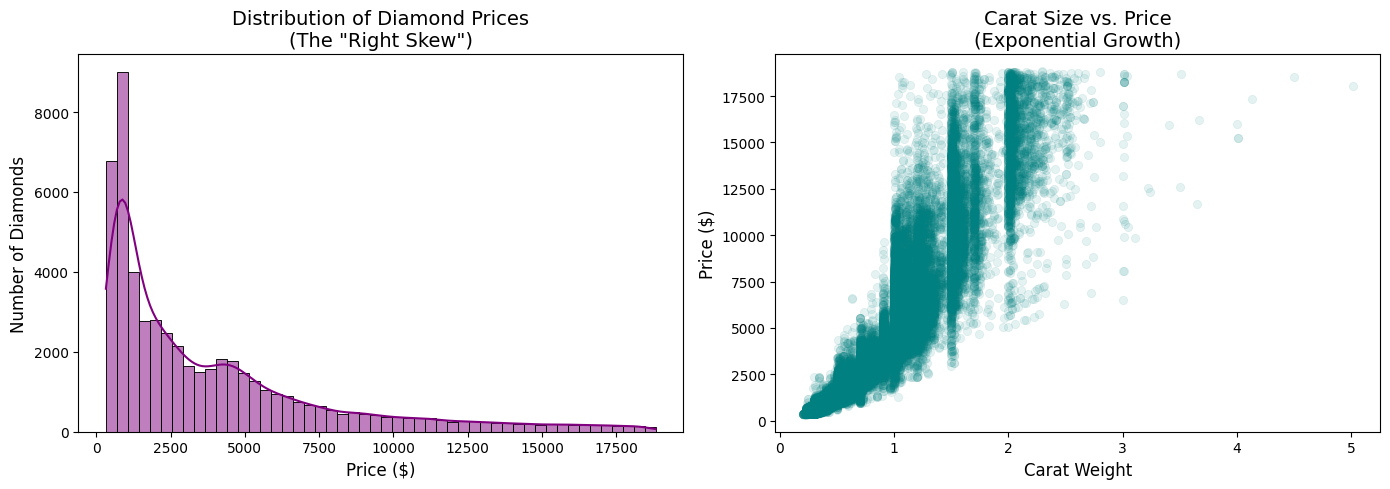

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('diamonds')

# Set up the matplotlib figure side-by-side
plt.figure(figsize=(14, 5))

# --- GRAPH 1: The Skewed Price Distribution ---
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Diamond Prices\n(The "Right Skew")', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of Diamonds', fontsize=12)

# --- GRAPH 2: Carat vs Price ---
plt.subplot(1, 2, 2)
# Using alpha=0.1 makes the dots transparent so we can see where they cluster heavily
sns.scatterplot(x='carat', y='price', data=df, alpha=0.1, color='teal', edgecolor=None)
plt.title('Carat Size vs. Price\n(Exponential Growth)', fontsize=14)
plt.xlabel('Carat Weight', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

## **Data Preprocessing**
Neural networks only understand numbers, so we must convert the text categories (cut, color, clarity) into 1s and 0s using One-Hot Encoding. Then, we separate our features ($X$) from our target ($y$) and scale the numerical data so large numbers (like price) don't overwhelm the network.

In [5]:
# 1. One-Hot Encode categorical variables
# drop_first=True prevents the "dummy variable trap" (multicollinearity)
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

# 2. Separate Features (X) and Target (y)
X = df_encoded.drop('price', axis=1).values
y = df_encoded['price'].values

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the features
# This is CRITICAL for Neural Networks so features have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Only transform the test set to prevent data leakage!

print(f"Number of input features: {X_train.shape[1]}")

Number of input features: 23


## **Creating PyTorch Tensors and DataLoaders**
Now we convert our cleaned NumPy arrays into PyTorch Tensors, and wrap them in a DataLoader to automatically handle our mini-batches during training.

In [6]:
# 1. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # Reshape to column vector

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# 2. Create Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3. Create DataLoaders (Batch size of 64)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## **Building the Feed-Forward Neural Network**
We will build a fully connected Feed-Forward Neural Network (often called a Multi-Layer Perceptron). Because this is a regression task (predicting a continuous price), our output layer will have exactly one neuron with no activation function.

In [7]:
class DiamondPricePredictor(nn.Module):
    def __init__(self, input_features, hidden1=32, hidden2=16, out=1):
        super().__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_features, hidden1) # Hidden layer 1
        self.layer2 = nn.Linear(hidden1, hidden2)             # Hidden layer 2
        self.output_layer = nn.Linear(hidden2, out)        # Output layer (1 predicted price)

        # Define the activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activations
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Instantiate the model
# X_train.shape[1] automatically passes the correct number of input features (23)
model = DiamondPricePredictor(input_features=X_train.shape[1])
print(model)

DiamondPricePredictor(
  (layer1): Linear(in_features=23, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


## **Training Setup (Loss and Optimizer)**
For regression, we use Mean Squared Error (MSE) to measure how far off our predicted prices are from the actual prices. We will use the Adam optimizer to adjust the weights.

In [8]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam (Learning rate of 0.01)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## **The Training Loop**
This is where the actual learning happens. For every epoch, the model looks at mini-batches, makes a prediction, calculates the loss, and updates its weights using backpropagation.

In [9]:
# Set the number of epochs
epochs = 100

train_losses = []

for epoch in range(epochs):
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        # 1. Forward pass: get predictions
        predictions = model(batch_X)

        # 2. Calculate loss
        loss = criterion(predictions, batch_y)

        # 3. Zero gradients, backward pass, and update weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Calculate average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)


    # Print progress every epochs
    #print(f'Epoch [{epoch+1}], Loss (MSE): {avg_loss:.2f}')
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss (MSE): {avg_loss:.2f}')

Epoch [10/100], Loss (MSE): 435693.52
Epoch [20/100], Loss (MSE): 417184.41
Epoch [30/100], Loss (MSE): 406957.69
Epoch [40/100], Loss (MSE): 401661.26
Epoch [50/100], Loss (MSE): 386045.95
Epoch [60/100], Loss (MSE): 376218.92
Epoch [70/100], Loss (MSE): 366218.37
Epoch [80/100], Loss (MSE): 350970.74
Epoch [90/100], Loss (MSE): 343593.64
Epoch [100/100], Loss (MSE): 327594.94


## **Evaluation and Making Predictions**
After training, we switch the model to .eval() mode and test it on data it has never seen before to make sure it can generalize.

Final Test Loss (MSE): 355827.53
Final Test RMSE: $596.51
R2 Score (Test Set): 0.9776
Mean Absolute Percentage Error (MAPE) on Test Set: 0.0980
------------------------------
Sample Predictions:
Actual Price: $559.00 | Predicted Price: $607.63 | Difference: $48.63
Actual Price: $2201.00 | Predicted Price: $2367.09 | Difference: $166.09
Actual Price: $1238.00 | Predicted Price: $1288.29 | Difference: $50.29
Actual Price: $1304.00 | Predicted Price: $1499.18 | Difference: $195.18
Actual Price: $6901.00 | Predicted Price: $9402.26 | Difference: $2501.26

--- Residuals Visualization ---


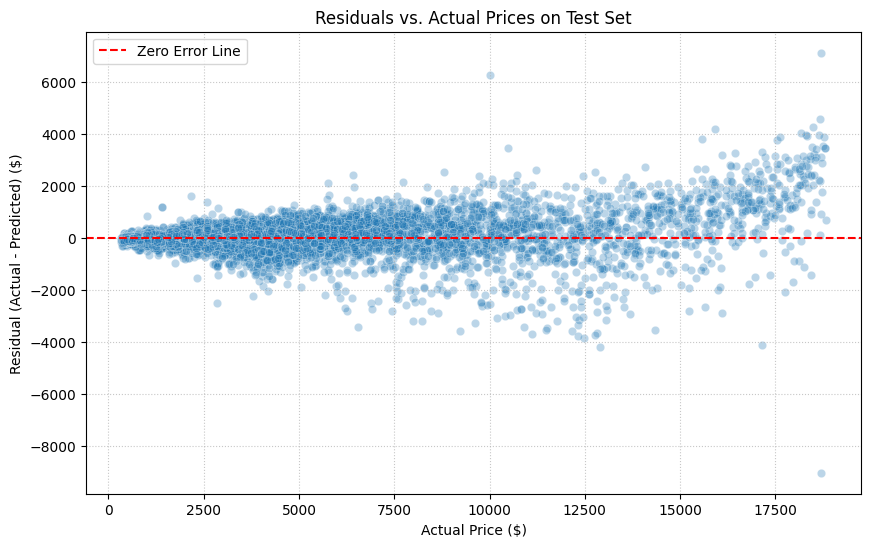

In [10]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error


# Switch to evaluation mode (turns off gradients to save memory and time)
model.eval()

with torch.no_grad():
    # Get predictions for the entire test set
    test_predictions = model(X_test_tensor)

    # Calculate test loss
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'Final Test Loss (MSE): {test_loss.item():.2f}')

    # Calculate RMSE (Root Mean Squared Error) to see average error in dollars
    rmse = torch.sqrt(test_loss)
    print(f'Final Test RMSE: ${rmse.item():.2f}')

    # Calculate R2 for Test Set
    r2_test = r2_score(y_test_tensor, test_predictions)
    print(f"R2 Score (Test Set): {r2_test:.4f}")

    # Calculate mean_absolute_percentage_error for Test Set
    mape = mean_absolute_percentage_error(y_test_tensor, test_predictions)
    print(f"Mean Absolute Percentage Error (MAPE) on Test Set: {mape:.4f}")



print("-" * 30)

# Let's look at the first 5 predictions vs actual prices
print("Sample Predictions:")
for i in range(5):
    actual = y_test_tensor[i].item()
    predicted = test_predictions[i].item()
    print(f"Actual Price: ${actual:.2f} | Predicted Price: ${predicted:.2f} | Difference: ${abs(actual-predicted):.2f}")



print("\n--- Residuals Visualization ---")
# Calculate residuals
residuals = y_test_tensor - test_predictions

# Plot residuals vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_tensor.flatten(), y=residuals.flatten(), alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')
plt.title('Residuals vs. Actual Prices on Test Set')
plt.xlabel('Actual Price ($)')
plt.ylabel('Residual (Actual - Predicted) ($)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

- **MSE** is the average of the squared differences between your predicted and actual prices. Because it squares the errors, it penalizes larger errors more heavily. However, since it's in squared dollars, it's not directly interpretable in a monetary sense.

- **RMSE (Root Mean Squared Error)** is the square root of MSE, bringing the error back into the original units of your target variable, which is dollars. This means, on average, our model's predictions are off by approximately $596.51, from the actual diamond prices on the test set.

- **The R2 scor**e, indicates the proportion of the variance in the dependent variable (diamond price) that is predictable from the independent variables (our diamond features). An R2 of 0.9776 means that model explains approximately 97.76% of the variability in diamond prices. An R2 value close to 1 is generally considered very good, indicating a strong fit.

- **MAPE** tells you the average percentage error of your predictions. A MAPE of 0.0980 means that, on average, our predictions are off by about 9.80% of the actual price. This metric is especially useful for understanding the relative error across different price ranges.


<br><br><br>

## **Can we do better?**

How about adding more layers and neurons?

In [11]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import numpy as np # Import numpy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# First Split: Carve out 15% for the locked-away Test Set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second Split: Split the remaining 85% into Train and Validation
# Taking 18% of the remaining data gives us roughly 15% of the total dataset for Validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)


# Scale the features properly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # FIT and transform the training data
X_val = scaler.transform(X_val)         # ONLY transform validation
X_test = scaler.transform(X_test)       # ONLY transform testing

print(f"Training rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Testing rows: {len(X_test)}")

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

# Create Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Training rows: 37596
Validation rows: 8253
Testing rows: 8091


In [12]:
class DiamondPricePredictor(nn.Module):
    def __init__(self, input_features, hidden1=128, hidden2=64, hidden3=32, hidden4=16, out=1):
        super().__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_features, hidden1) # Hidden layer 1
        self.layer2 = nn.Linear(hidden1, hidden2)             # Hidden layer 2
        self.layer3 = nn.Linear(hidden2, hidden3)
        self.layer4 = nn.Linear(hidden3, hidden4)
        self.output_layer = nn.Linear(hidden4, out)        # Output layer (1 predicted price)

        # Define the activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activations
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.output_layer(x) # No activation at the end for regression
        return x

# Instantiate the model
# X_train.shape[1] automatically passes the correct number of input features (23)
model = DiamondPricePredictor(input_features=X_train.shape[1])
print(model)

DiamondPricePredictor(
  (layer1): Linear(in_features=23, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (layer4): Linear(in_features=32, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [13]:

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 200

train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- 1. TRAINING PHASE ---
    model.train()
    epoch_train_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- 2. VALIDATION PHASE ---
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            val_loss = criterion(predictions, batch_y)
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}')

Epoch [10/200] | Train Loss: 434224.71702 | Val Loss: 461950.92516
Epoch [20/200] | Train Loss: 402578.79844 | Val Loss: 463938.98631
Epoch [30/200] | Train Loss: 381804.99160 | Val Loss: 450831.87252
Epoch [40/200] | Train Loss: 364739.72287 | Val Loss: 402393.79854
Epoch [50/200] | Train Loss: 339827.42380 | Val Loss: 380571.84932
Epoch [60/200] | Train Loss: 318040.34890 | Val Loss: 354734.42518
Epoch [70/200] | Train Loss: 307309.59913 | Val Loss: 342856.97652
Epoch [80/200] | Train Loss: 296980.77138 | Val Loss: 338915.35828
Epoch [90/200] | Train Loss: 292181.06196 | Val Loss: 330911.11142
Epoch [100/200] | Train Loss: 288291.12031 | Val Loss: 320122.86066
Epoch [110/200] | Train Loss: 283061.69349 | Val Loss: 323476.97263
Epoch [120/200] | Train Loss: 278941.80230 | Val Loss: 329360.08506
Epoch [130/200] | Train Loss: 277695.07315 | Val Loss: 324917.62944
Epoch [140/200] | Train Loss: 274081.45308 | Val Loss: 324265.89894
Epoch [150/200] | Train Loss: 272708.21381 | Val Loss: 34

Final Test Loss (MSE): 343467.18750
Final Test RMSE: $586.06073
R2 Score (Test Set): 0.97855
Mean Absolute Percentage Error (MAPE) on Test Set: 0.08805
------------------------------
Sample Predictions:
Actual Price: $559.00 | Predicted Price: $644.51 | Difference: $85.51
Actual Price: $2201.00 | Predicted Price: $2315.71 | Difference: $114.71
Actual Price: $1238.00 | Predicted Price: $1201.95 | Difference: $36.05
Actual Price: $1304.00 | Predicted Price: $1418.60 | Difference: $114.60
Actual Price: $6901.00 | Predicted Price: $10651.21 | Difference: $3750.21

--- Residuals Visualization ---


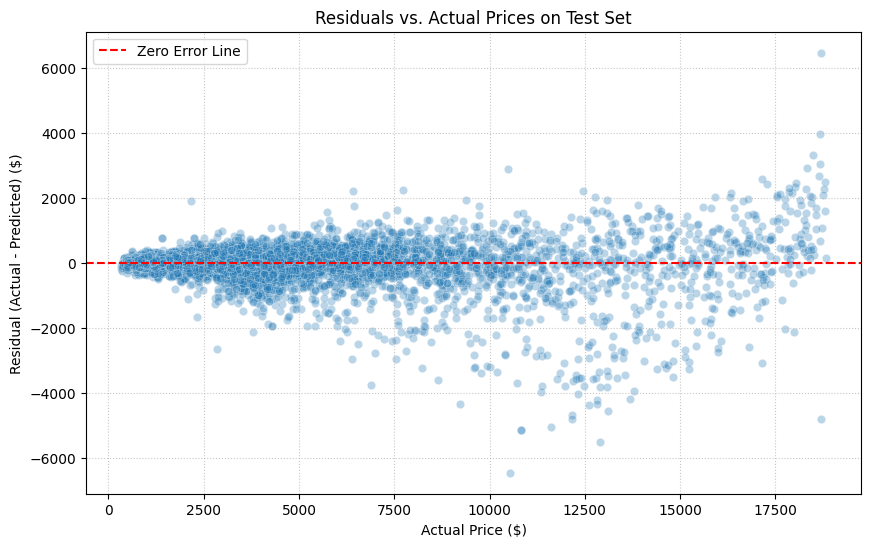

In [14]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error


# Switch to evaluation mode (turns off gradients to save memory and time)
model.eval()

with torch.no_grad():
    # Get predictions for the entire test set
    test_predictions = model(X_test_tensor)

    # Calculate test loss
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'Final Test Loss (MSE): {test_loss.item():.5f}')

    # Calculate RMSE (Root Mean Squared Error) to see average error in dollars
    rmse = torch.sqrt(test_loss)
    print(f'Final Test RMSE: ${rmse.item():.5f}')

    # Calculate R2 for Test Set
    r2_test = r2_score(y_test_tensor, test_predictions)
    print(f"R2 Score (Test Set): {r2_test:.5f}")

    # Calculate mean_absolute_percentage_error for Test Set
    mape = mean_absolute_percentage_error(y_test_tensor, test_predictions)
    print(f"Mean Absolute Percentage Error (MAPE) on Test Set: {mape:.5f}")



print("-" * 30)

# Let's look at the first 5 predictions vs actual prices
print("Sample Predictions:")
for i in range(5):
    actual = y_test_tensor[i].item()
    predicted = test_predictions[i].item()
    print(f"Actual Price: ${actual:.2f} | Predicted Price: ${predicted:.2f} | Difference: ${abs(actual-predicted):.2f}")



print("\n--- Residuals Visualization ---")
# Calculate residuals
residuals = y_test_tensor - test_predictions

# Plot residuals vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_tensor.flatten(), y=residuals.flatten(), alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')
plt.title('Residuals vs. Actual Prices on Test Set')
plt.xlabel('Actual Price ($)')
plt.ylabel('Residual (Actual - Predicted) ($)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

Adding more layers and neurons generally improves a model's ability to learn complex, hierarchical patterns, often outperforming wider, shallow networks. While deeper networks increase abstraction (layers) and capacity (neurons), they significantly increase the risk of **overfitting**, **vanishing gradients**, and **higher computational costs**.


#### **Impact of Adding More Layers vs. Neurons**

- **More Layers (Deeper):** Improves performance by allowing hierarchical feature learning—earlier layers detect simple edges, while later layers combine these into complex shapes. This is generally more efficient than just adding neurons.

- **More Neurons (Wider):** Increases the network's capacity to learn more features, but adding too many can make the model "scattered" and difficult to optimize, reducing generalization.

#### **Why "More" Isn't Always Better**
- **Overfitting:** Too many neurons/layers allow the model to memorize the training data rather than generalize, resulting in poor test accuracy.

- **Vanishing/Exploding Gradients:** Deep networks can become difficult to train as gradients become too small or too large, making convergence slow or impossible.

- **Diminishing Returns:** Added complexity requires significantly more data and training time for minor accuracy improvements.

### **Visualizing Overfitting**

- **The Training-Validation Gap:** Monitor the difference between your training metrics and validation metrics. A significant gap—where training accuracy is very high but validation accuracy is much lower—is a primary sign that the model has memorized the training set rather than learning general patterns.

- **Loss Curve Divergence:** Plot your loss over time (epochs). In a healthy model, both training and validation loss decrease together. If the training loss continues to drop while the validation loss starts to rise, your model is officially overfitting.

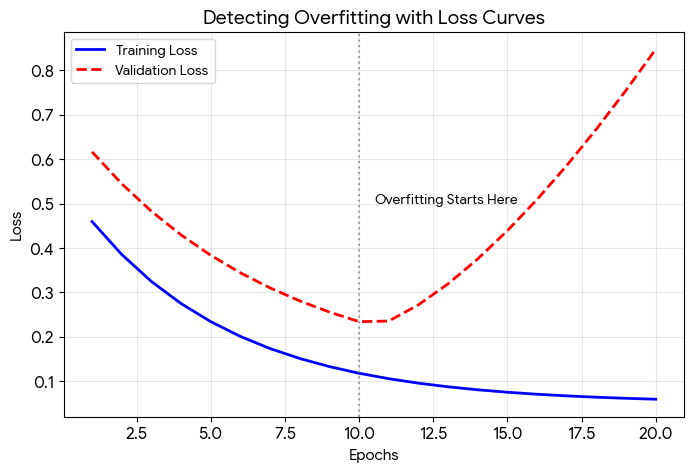

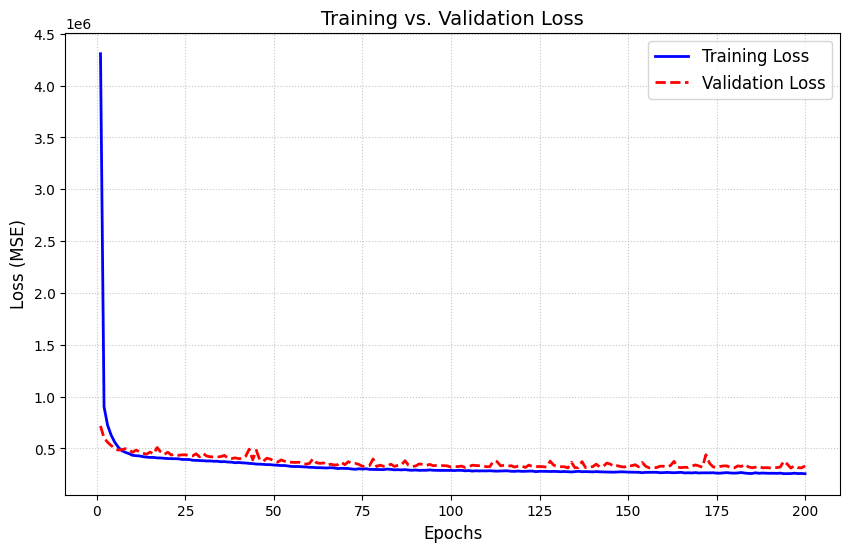

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

<br><br><br><br>

## **Let's find the root cause of issue and fix that**

In the Diamond dataset (and many economic datasets), the price of a diamond often follows a Power Law. Small, common diamonds are cheap and plentiful, while large, high-quality diamonds are exponentially more expensive and rare.

**How did we locate the "Log Behavior"?**
We don't just guess; we use specific diagnostic tools to see if the data is begging for a transformation.

- **The Histogram (The Eyeball Test)**
  If you plot sns.histplot(df['price']), you won't see a bell curve. You will see a giant spike on the left and a very long, thin tail stretching to the right. This "Right Skew" is the classic signal for a Log transform.

- **High Skewness Coefficient**
  In Python, you can run `df['price'].skew()`.

  If the value is greater than 1, the data is highly skewed.

  If `np.log1p(df['price']).skew()` results in a value closer to 0, the transformation was successful.

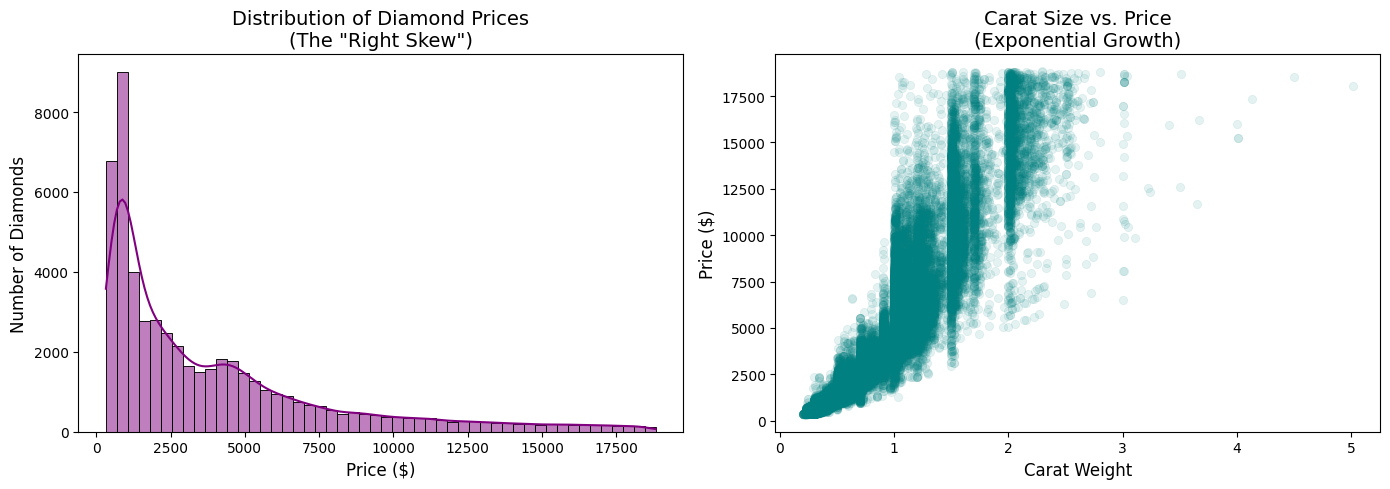

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = sns.load_dataset('diamonds')

# Set up the matplotlib figure side-by-side
plt.figure(figsize=(14, 5))

# --- GRAPH 1: The Skewed Price Distribution ---
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Diamond Prices\n(The "Right Skew")', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of Diamonds', fontsize=12)

# --- GRAPH 2: Carat vs Price ---
plt.subplot(1, 2, 2)
# Using alpha=0.1 makes the dots transparent so we can see where they cluster heavily
sns.scatterplot(x='carat', y='price', data=df, alpha=0.1, color='teal', edgecolor=None)
plt.title('Carat Size vs. Price\n(Exponential Growth)', fontsize=14)
plt.xlabel('Carat Weight', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
df['price'].skew()

np.float64(1.618395283383529)

In [17]:
np.log1p(df['price']).skew()

np.float64(0.115926478802339)

In [18]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import numpy as np # Import numpy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. First Split: Carve out 15% for the locked-away Test Set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 2. Second Split: Split the remaining 85% into Train and Validation
# Taking 18% of the remaining data gives us roughly 15% of the total dataset for Validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

# 3. Apply Log Transformation to Target Variables
# Using log1p (log(1+x)) to handle potential zero values gracefully
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

# 4. Scale the features properly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # FIT and transform the training data
X_val = scaler.transform(X_val)         # ONLY transform validation
X_test = scaler.transform(X_test)       # ONLY transform testing

print(f"Training rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Testing rows: {len(X_test)}")

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1) # Reshape for PyTorch

# Create Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Training rows: 37596
Validation rows: 8253
Testing rows: 8091


In [ ]:
class DiamondPricePredictor(nn.Module):
    def __init__(self, input_features, hidden1=32, hidden2=16, hidden3=8, hidden4=4, out=1):
        super().__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_features, hidden1) # Hidden layer 1
        self.layer2 = nn.Linear(hidden1, hidden2)             # Hidden layer 2
        self.layer3 = nn.Linear(hidden2, hidden3)
        self.layer4 = nn.Linear(hidden3, hidden4)
        self.output_layer = nn.Linear(hidden4, out)        # Output layer (1 predicted price)

        # Define the activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activations
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.output_layer(x) # No activation at the end for regression
        return x

# Instantiate the model
# X_train.shape[1] automatically passes the correct number of input features (23)
model = DiamondPricePredictor(input_features=X_train.shape[1])
print(model)

DiamondPricePredictor(
  (layer1): Linear(in_features=23, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (layer3): Linear(in_features=16, out_features=8, bias=True)
  (layer4): Linear(in_features=8, out_features=4, bias=True)
  (output_layer): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 200

train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- 1. TRAINING PHASE ---
    model.train()
    epoch_train_loss = 0

    for batch_X, batch_y in train_loader:

        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- 2. VALIDATION PHASE ---
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            val_loss = criterion(predictions, batch_y)
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}')

Epoch [10/200] | Train Loss: 0.01878 | Val Loss: 0.01885
Epoch [20/200] | Train Loss: 0.01636 | Val Loss: 0.01692
Epoch [30/200] | Train Loss: 0.01566 | Val Loss: 0.01553
Epoch [40/200] | Train Loss: 0.01528 | Val Loss: 0.01532
Epoch [50/200] | Train Loss: 0.01481 | Val Loss: 0.01722
Epoch [60/200] | Train Loss: 0.01428 | Val Loss: 0.01664
Epoch [70/200] | Train Loss: 0.01405 | Val Loss: 0.01445
Epoch [80/200] | Train Loss: 0.01380 | Val Loss: 0.01535
Epoch [90/200] | Train Loss: 0.01364 | Val Loss: 0.01402
Epoch [100/200] | Train Loss: 0.01341 | Val Loss: 0.01363
Epoch [110/200] | Train Loss: 0.01317 | Val Loss: 0.01420
Epoch [120/200] | Train Loss: 0.01295 | Val Loss: 0.01411
Epoch [130/200] | Train Loss: 0.01295 | Val Loss: 0.01281
Epoch [140/200] | Train Loss: 0.01252 | Val Loss: 0.01269
Epoch [150/200] | Train Loss: 0.01231 | Val Loss: 0.01292
Epoch [160/200] | Train Loss: 0.01212 | Val Loss: 0.01371
Epoch [170/200] | Train Loss: 0.01196 | Val Loss: 0.01254
Epoch [180/200] | Train

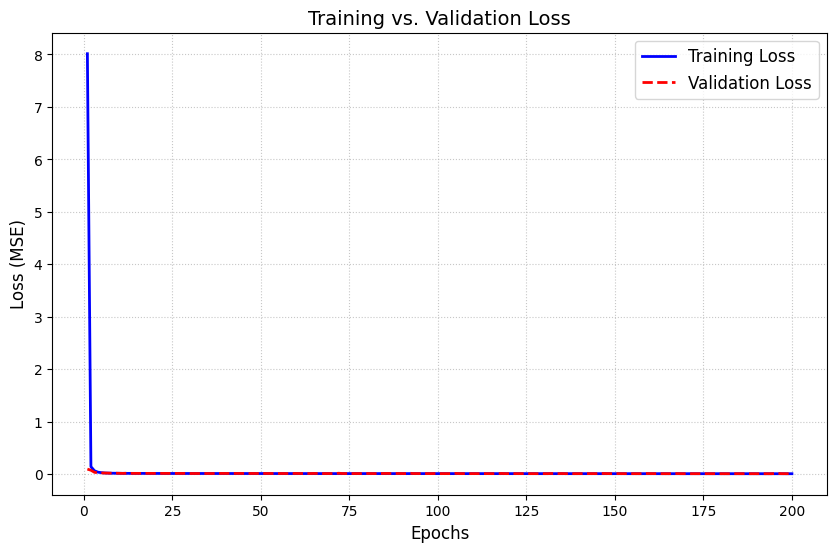

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Final Test Loss (MSE): 0.01157
Final Test RMSE: $0.10756
R2 Score (Test Set): 0.98880
Mean Absolute Percentage Error (MAPE) on Test Set: 0.01057
------------------------------
Sample Predictions:
Actual Price: $6.33 | Predicted Price: $6.42 | Difference: $0.10
Actual Price: $7.70 | Predicted Price: $7.79 | Difference: $0.10
Actual Price: $7.12 | Predicted Price: $7.13 | Difference: $0.01
Actual Price: $7.17 | Predicted Price: $7.31 | Difference: $0.14
Actual Price: $8.84 | Predicted Price: $9.11 | Difference: $0.27

--- Residuals Visualization ---


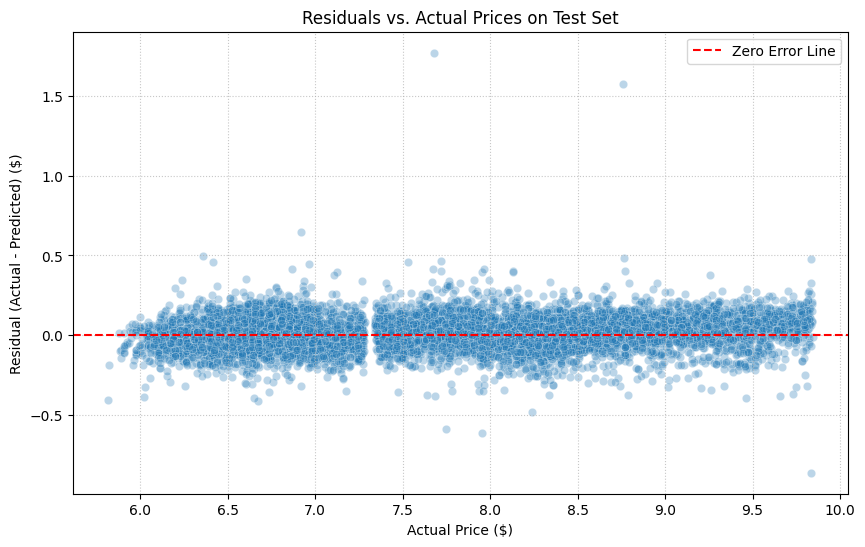

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error


# Switch to evaluation mode (turns off gradients to save memory and time)
model.eval()

with torch.no_grad():
    # Get predictions for the entire test set
    test_predictions = model(X_test_tensor)

    # Calculate test loss
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'Final Test Loss (MSE): {test_loss.item():.5f}')

    # Calculate RMSE (Root Mean Squared Error) to see average error in dollars
    rmse = torch.sqrt(test_loss)
    print(f'Final Test RMSE: ${rmse.item():.5f}')

    # Calculate R2 for Test Set
    r2_test = r2_score(y_test_tensor, test_predictions)
    print(f"R2 Score (Test Set): {r2_test:.5f}")

    # Calculate mean_absolute_percentage_error for Test Set
    mape = mean_absolute_percentage_error(y_test_tensor, test_predictions)
    print(f"Mean Absolute Percentage Error (MAPE) on Test Set: {mape:.5f}")



print("-" * 30)

# Let's look at the first 5 predictions vs actual prices
print("Sample Predictions:")
for i in range(5):
    actual = y_test_tensor[i].item()
    predicted = test_predictions[i].item()
    print(f"Actual Price: ${actual:.2f} | Predicted Price: ${predicted:.2f} | Difference: ${abs(actual-predicted):.2f}")



print("\n--- Residuals Visualization ---")
# Calculate residuals
residuals = y_test_tensor - test_predictions

# Plot residuals vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_tensor.flatten(), y=residuals.flatten(), alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')
plt.title('Residuals vs. Actual Prices on Test Set')
plt.xlabel('Actual Price ($)')
plt.ylabel('Residual (Actual - Predicted) ($)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

**Crucial Note:** If later you git new samples that does not have a target (y), you cannot log-transform it!

You only transform the $y$ during training/validation.When you get your final predictions ($\hat{y}$), they will be in "Log Space." To get the actual dollar amount, you must perform the Inverse Transformation:$$Price_{final} = e^{\hat{y}} - 1$$In Python, this is simply: `final_preds = np.expm1(model_output)`.

<br>

 **Investigating the 'Gap' in Actual Log-Transformed Prices**

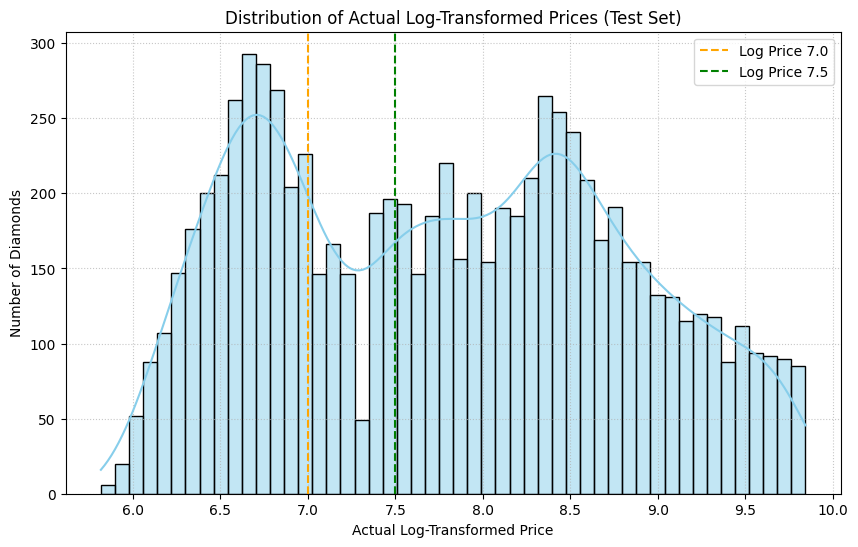

Number of diamonds in the test set with actual log-transformed price between 7.0 and 7.5: 926


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert y_test_tensor to a NumPy array for easier analysis
y_test_numpy = y_test_tensor.cpu().numpy().flatten()

plt.figure(figsize=(10, 6))
sns.histplot(y_test_numpy, bins=50, kde=True, color='skyblue')
plt.axvline(x=7.0, color='orange', linestyle='--', label='Log Price 7.0')
plt.axvline(x=7.5, color='green', linestyle='--', label='Log Price 7.5')
plt.title('Distribution of Actual Log-Transformed Prices (Test Set)')
plt.xlabel('Actual Log-Transformed Price')
plt.ylabel('Number of Diamonds')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Count data points in the specific range
lower_bound = 7.0
upper_bound = 7.5
count_in_range = np.sum((y_test_numpy >= lower_bound) & (y_test_numpy < upper_bound))

print(f"Number of diamonds in the test set with actual log-transformed price between {lower_bound} and {upper_bound}: {count_in_range}")

**Why Lower Density in Certain Price Ranges?**

The observed lower density in the log-transformed price range of 7.0-7.5 (approx. $1,095-$1,807) is characteristic of the real diamond market. This is primarily due to:

1.  **Carat Weight Thresholds:** Significant price jumps occur at 'magic' carat weights (e.g., 0.5, 1.0, 1.5 carats), making diamonds just below these thresholds much cheaper per carat and creating price gaps.
2.  **Market Segmentation:** Diamonds are often priced to fit specific consumer segments. The 7.0-7.5 log-price range might represent an 'in-between' segment with lower demand compared to entry-level or higher-end engagement ring diamonds.
3.  **Optimization by Cutters:** Diamond cutters prioritize maximizing value, which can lead to fewer diamonds naturally falling into certain intermediate price categories.

This is not a data anomaly, but a reflection of the diamond industry's pricing structure and consumer preferences.

<br><br>

## **Variation in Creating Models**



Notice how repetitive this is getting? `x = layer1(x), x = relu(x), x = layer2(x)...` If we build a 50-layer network, writing this forward function is going to be incredibly annoying. What if there was a shortcut for networks that just go in a straight line?

In [ ]:
class DiamondPricePredictor(nn.Module):
    def __init__(self, input_features, hidden1=16, hidden2=8, out=1):
        super().__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_features, hidden1) # Hidden layer 1
        self.layer2 = nn.Linear(hidden1, hidden2)             # Hidden layer 2
        self.output_layer = nn.Linear(hidden2, out)        # Output layer (1 predicted price)

        # Define the activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activations
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output_layer(x) # No activation at the end for regression
        return x

# Instantiate the model
# X_train.shape[1] automatically passes the correct number of input features (23)
model = DiamondPricePredictor(input_features=X_train.shape[1])
print(model)

DiamondPricePredictor(
  (layer1): Linear(in_features=23, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


PyTorch has a built-in container called Sequential. You just pack your layers into it in the exact order you want them to run, and it handles the forward pass for you automatically!

In [ ]:
import torch.nn as nn

class DiamondPricePredictorSequential(nn.Module):
    def __init__(self, input_features, hidden1=16, hidden2=8, out=1):
        super().__init__()

        # We pack the dynamic layers and activations into a single pipeline
        self.model = nn.Sequential(
            nn.Linear(input_features, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, out)
        )

    def forward(self, x):
        # We just hand the data to the pipeline, and it handles the routing!
        return self.model(x)

# It is instantiated the exact same way
model = DiamondPricePredictorSequential(input_features=23)
print(model)

DiamondPricePredictorSequential(
  (model): Sequential(
    (0): Linear(in_features=23, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


 **The Problem:** What if I want to write a loop to test models with 1 layer, 5 layers, and 50 layers. I don't want to manually type self.layer1 through self.layer50!

In [ ]:
import torch.nn as nn

class DiamondListPredictor(nn.Module):
    # Instead of passing hidden1 and hidden2, we pass a list of ANY length!
    def __init__(self, input_features, hidden_layers=[64, 32, 16, 8]):
        super().__init__()

        # 1. Create an empty ModuleList
        self.layers = nn.ModuleList()

        # 2. Automatically build the network using a loop!
        current_dim = input_features
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(current_dim, hidden_dim))
            current_dim = hidden_dim # The output of this layer is the input for the next

        # 3. The final output layer
        self.output_layer = nn.Linear(current_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # We also use a loop in the forward pass!
        for layer in self.layers:
            x = self.relu(layer(x))

        x = self.output_layer(x)
        return x

# Now a student can build a massive network with just one line of code:
massive_model = DiamondListPredictor(input_features=23, hidden_layers=[128, 64, 64, 32, 32, 16])

#### **The Comparison: Container vs. Modular vs Dynamic List**
- **The nn.Sequential Style (The "Container" Approach)**

  **How it works:** You pack all your layers and activation functions into a single "container" called nn.Sequential(). In the forward pass, you just hand the data to the container, and it automatically passes the data through each layer in the exact order you listed them.

  **The Pros:** It is incredibly clean, concise, and easy to read. It requires very little code.

  **The Cons:** It is completely rigid. It only works for simple "feed-forward" networks where data moves in a straight line from Layer A to Layer B to Layer C.

- **"Our Style" (The "Modular" Approach)**

  **How it works:** You define every layer as an individual tool in the __init__, and then you manually connect them step-by-step in the forward pass.

  **The Pros:** Absolute flexibility. This is how professional, complex AI models are built. If you want data to skip a layer (like in a ResNet), if you have two separate inputs, or if you just want to put a print(x.shape) in the middle of the network to debug a math error, you must use this style.

  **The Cons:** It is a bit more verbose and repetitive to type out.

- **The "Dynamic List" Style (nn.ModuleList)**

  **How it works:** You create an empty nn.ModuleList() container and append your individual PyTorch layers to it, usually using a Python for loop. It acts exactly like a standard Python list, but it tells PyTorch's background registry to track and update the weights of every layer inside it. In the forward pass, you write another loop to push the data through each layer one by one.

  **The Pros:** Unmatched scalability for hyperparameter tuning. You can instantly change a network from 2 layers to 200 layers just by changing a single list of numbers in your arguments. It eliminates massive, repetitive blocks of code when building deep, repetitive networks.

  **The Cons:** It requires a slightly higher level of Python knowledge (loops and dynamic variable updating). Also, unlike nn.Sequential, it does not handle the data routing automatically—you still have to manually write the loop in the forward pass to ensure the data moves from one layer to the next.